<a href="https://colab.research.google.com/github/embark-cybertraining/embark-scratch-notebooks/blob/main/sessions_1_and_2/ooi_cruises_bcodmo_session1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prototype notebook for EMBARK CyberTraining Session 1

## Use Case Goal:

An oceanographer would like to visualize salinity by depth at a deep ocean study site with multiple cruises over several years.
As a CI user, s/he will (find), access, and use data from external sources to plot salinity by depth over a several-year time period for a location in which some of the profiles were collected by ship-based CTD rosette casts and others were sensed by Argo floats.

* Data repositories: BCO-DMO, NCEI
* Ocean observing systems: Argo, U.S. NSF OOI

* Tools include: ERDDAP, Python software libraries (e.g., pandas, erddapy, argopy)

This notebook may be run locally, or within cloud-based computing infrastructure (e.g., Google Colab, OOI JupyterHub).

## Session 1 (this notebook)
Visualize 10 years of discrete water sampling data from annual research cruises and overlay with post-calibrated, ship-cast CTD profiles
## Session 2 (in a separate notebook)
Fill in the time gaps between research cruises with CTD profile data from autonomous floats

## Credits for this notebook
* The first portion builds on a notebook from the OOI CGSN Data Team https://github.com/WHOIGit/ooi-on-bco-dmo/blob/main/notebooks/0-OOI-Irminger-discrete-sample-article-figures.ipynb
* Overall the notebook was developed by the EMBARK CyberTraining project team, including Amber York, Sage Lichtenwalner, and Stace Beaulieu.
* Where indicated, some code was generated or improved by AI coding assistance, including ChatGPT.

# Setup

In [1]:
#install libraries directly into the current kernel's environment if dependency not found
# TODO: add pandas and matplotlib explicitly even if already in current env (for saftety when using in other environments)
try:
    import cmocean.cm as cmo
except ImportError:
    %pip install -q cmocean

# consider remove the cmocean package and just use viridis

In [2]:
# TODO: print versions of critical packages loaded for provenance purposes (pandas, etc)
#  print(mpl.__version__) # if plot cell results in error check version of matplotlib

In [3]:
# Import modules
# note this does not yet include folium for Session 1
# does not yet include argopy, plotly, numpy for Session 2
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
import matplotlib.cm as cm
from matplotlib.dates import AutoDateLocator, AutoDateFormatter
import cmocean.cm as cmo # colormaps for commonly-used oceanographic variables

In [4]:
#planning df name consistency changes
#step 1
# df_ctd_discr_all -> full dataset
# df_ctd_discr_all_qc -> limited to only where salinity is good

#step2 - access subset data from ERDDAP using url load (try qc'ed on load - else subset after)
# df_ctd_discr_spatial_erddap_url -> dataset geospatial subset loaded from ERDDAP URL (or subset after load)
# df_ctd_discr_spatial_erddap_url_qc -> same as above but filterd by only good salinity

#step3 - access subset data from ERDDAP using erdappy library (try qc'ed on load - else subset after)
# df_ctd_discr_spatial_erddapy
# df_ctd_discr_spatial_erddapy_qc


# SESSION 1
Visualize 10 years of discrete water sampling data from annual research cruises and overlay with post-calibrated, ship-cast CTD profiles

We will use cruises to the U.S. NSF OOI Global Irminger Sea Array https://oceanobservatories.org/array/global-irminger-sea-array/.

Discrete water samples were collected not only for post-cal'g ship-cast CTD sensors but also for in situ mooring-mounted sensors.

# DATASET 1 - Discrete water sampling data from research cruises

## Find Data
The CI user already will have used other tools to search for "Irminger Sea discrete water sampling" and find:
* Dataset: OOI Global Irminger Sea Array CTD and Discrete Water Sampling Data from Mooring Overturning Cruises in the Irminger Sea from 2014-2023 (OOI Cruise Data project)
* **Dataset Landing Page: https://www.bco-dmo.org/dataset/911407**



## Inspect data/metadata for context


Inspect the dataset landing page metadata for context for your analysis.

This dataset also is provided through ERDDAP; you can use the ERDDAP Make A Graph tool to confirm your desired location, time period, and parameters are in the dataset: https://erddap.bco-dmo.org/erddap/tabledap/bcodmo_dataset_911407_v1.graph




### Review the data license

Check the license to make sure your intended use is allowed.

## Access Data without downloading the file

### Load entire Discrete water sampling data table using HTTPS URL


To access the data in comma separated variable (CSV) format, one can either:
1. Access the File through the URL. For example, on the Dataset Landing Page https://www.bco-dmo.org/dataset/911407 (copy csv download link).
2. Access a data table from an ERDDAP URL. Generate a URL using the [ERDDAP Data Access Form](https://erddap.bco-dmo.org/erddap/tabledap/bcodmo_dataset_911407_v1.html)
      - If using the ERDDAP Data Access Form, file type .csvp provides a single header row.
      - Note: If using the ERDDAP Data Access Form, one can subset (e.g., select variables of interest, and ranges within variables) prior to loading the data.
3. Access data from ERDDAP using a software library called erdappy.

# Access Strategy 1: Load from a file using a URL

In [5]:
# link to the public dataset CSV
# link obtained by copying the download button for the csv Data file showing on
# Dataset Landing Page https://www.bco-dmo.org/dataset/911407

bcodmo_data_url = "https://datadocs.bco-dmo.org/dataset/911407/file/vmvAX9NU4gqY2V/911407_v1_ooi_irminger_sea_discrete_water_sampling_data.csv"

# Load the OOI data into a dataframe
df_ctd_discr_all = pd.read_csv(bcodmo_data_url)

# Call head() to check that the data was imported correctly
df_ctd_discr_all.head()

,Cruise,Station,Target_Asset,Start_Latitude,Start_Longitude,Start_Time,Cast,Cast_Flag,Bottom_Depth_at_Start_Position,CTD_File,...,Discrete_pH_Replicate_Flag,Calculated_Alkalinity,Calculated_DIC,Calculated_pCO2,Calculated_pH,Calculated_CO2aq,Calculated_Bicarb,Calculated_CO3,Calculated_Omega_C,Calculated_Omega_A
0,KN221-04,1,Test Site #1,62.107,-31.381667,2014-09-08T11:39:06.000Z,1,*0000000000000100,NaN,KN22104001.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,KN221-04,1,Test Site #1,62.107,-31.381667,2014-09-08T11:39:06.000Z,1,*0000000000000100,NaN,KN22104001.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,KN221-04,1,Test Site #1,62.107,-31.381667,2014-09-08T11:39:06.000Z,1,*0000000000000100,NaN,KN22104001.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,KN221-04,1,Test Site #1,62.107,-31.381667,2014-09-08T11:39:06.000Z,1,*0000000000000100,NaN,KN22104001.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,KN221-04,1,Test Site #1,62.107,-31.381667,2014-09-08T11:39:06.000Z,1,*0000000000000100,NaN,KN22104001.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df_ctd_discr_all.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1937 entries, 0 to 1936
Data columns (total 80 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Cruise                                1937 non-null   object 
 1   Station                               1937 non-null   object 
 2   Target_Asset                          1937 non-null   object 
 3   Start_Latitude                        1937 non-null   float64
 4   Start_Longitude                       1937 non-null   float64
 5   Start_Time                            1937 non-null   object 
 6   Cast                                  1937 non-null   object 
 7   Cast_Flag                             1936 non-null   object 
 8   Bottom_Depth_at_Start_Position        1864 non-null   float64
 9   CTD_File                              1901 non-null   object 
 10  CTD_File_Flag                         1900 non-null   object 
 11  Niskin_Bottle_Pos

note the first rows of the data indicate a test cast outside of our desired study area

## Transform data (if needed)
Convert relevant parameters to datetime if needed

In [7]:
# Convert the CTD Bottle Closure Time to a datetime data type
df_ctd_discr_all["CTD_Bottle_Closure_Time"] = pd.to_datetime(df_ctd_discr_all["CTD_Bottle_Closure_Time"], yearfirst=True, utc=True)
df_ctd_discr_all.dtypes["CTD_Bottle_Closure_Time"]

datetime64[ns, UTC]

## Apply QC flags
For functions to interpret OOI discrete sample CTD flags to QARTOD QC-flags please see bottles.py file in https://github.com/oceanobservatories/ooi-data-explorations.

In [8]:
# display unique Discrete Sample flags
df_ctd_discr_all.Discrete_Salinity_Flag.unique() # display unique for parameter of interest
# pd.unique(ooi_irm[["Discrete_Oxygen_Flag", "Discrete_Salinity_Flag", "Discrete_Nutrients_Flag"]].values.ravel('K')) # display unique multiple columns

array([nan, '*0000000000000100', '*0000000000001001', '*0000000000000101'],
      dtype=object)

In [9]:
#TODO: Add description of QC stragegy in this code block

#TODO: evaluate alternate strategy using regex (good is if 1 is in third from last position)

# Assign "Acceptable" flags to QARTOD
flag1 = "*0000000000000100" # Good 1 in Bit Position 2 (i.e., 3rd from right)
flag2 = "*0000000000000101" # this example had 2 unique "Acceptable" flags

#ooi_irm.loc[ooi_irm.Discrete_Oxygen_Flag == flag1, 'Discrete_Oxygen_Flag'] = 1       # assign QARTOD Good
#ooi_irm.loc[ooi_irm.Discrete_Oxygen_Flag == flag2, 'Discrete_Oxygen_Flag'] = 1       # assign QARTOD Good
df_ctd_discr_all.loc[df_ctd_discr_all.Discrete_Salinity_Flag == flag1, 'Discrete_Salinity_Flag'] = 1   # assign QARTOD Good
df_ctd_discr_all.loc[df_ctd_discr_all.Discrete_Salinity_Flag == flag2, 'Discrete_Salinity_Flag'] = 1   # assign QARTOD Good


# again display unique Discrete Sample flags
df_ctd_discr_all.Discrete_Salinity_Flag.unique() # display unique for parameter of interest


array([nan, 1, '*0000000000001001'], dtype=object)

In [10]:
# Subset Data Frame to Discrete Samples with Acceptable flags
df_ctd_discr_all_qc = df_ctd_discr_all.query("Discrete_Salinity_Flag==1")

print(f"This subset of Discrete Samples with Acceptable flags reduced the total data points from {len(df_ctd_discr_all)} to {len(df_ctd_discr_all_qc)}")

This subset of Discrete Samples with Acceptable flags reduced the total data points from 1937 to 1072


In [11]:
# Call head() to view subset of Discrete Samples with Acceptable flags
df_ctd_discr_all_qc.head()

,Cruise,Station,Target_Asset,Start_Latitude,Start_Longitude,Start_Time,Cast,Cast_Flag,Bottom_Depth_at_Start_Position,CTD_File,...,Discrete_pH_Replicate_Flag,Calculated_Alkalinity,Calculated_DIC,Calculated_pCO2,Calculated_pH,Calculated_CO2aq,Calculated_Bicarb,Calculated_CO3,Calculated_Omega_C,Calculated_Omega_A
12,KN221-04,2,Test Site #2,61.995333,-31.8725,2014-09-08T14:44:00.000Z,2,*0000000000000100,2698.0,KN22104002.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,KN221-04,2,Test Site #2,61.995333,-31.8725,2014-09-08T14:44:00.000Z,2,*0000000000000100,2698.0,KN22104002.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,KN221-04,2,Test Site #2,61.995333,-31.8725,2014-09-08T14:44:00.000Z,2,*0000000000000100,2698.0,KN22104002.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,KN221-04,2,Test Site #2,61.995333,-31.8725,2014-09-08T14:44:00.000Z,2,*0000000000000100,2698.0,KN22104002.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,KN221-04,2,Test Site #2,61.995333,-31.8725,2014-09-08T14:44:00.000Z,2,*0000000000000100,2698.0,KN22104002.hex,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


note the first rows of this particular subset of data still indicate a test cast outside of our desired study area


If we do not subset to our desired region of interest, the first plot over time that we make below will include irrelevant data.
We could proceed with the next code cell to subset to our desired region of interest.

In [12]:
# For indexing plots with matplotlib
#flag_oxy = irm_qc["Discrete_Oxygen_Flag"]==1
flag_sal = df_ctd_discr_all_qc["Discrete_Salinity_Flag"]==1

In [13]:
# # Keep this cell to demonstrate efficiency using ERDDAP to subset prior to loading data
# # Use code within notebook to subset to just the area (and time) of interest
# # Bounds
# LON_MIN, LON_MAX = -40, -39
# LAT_MIN, LAT_MAX = 59.5, 60.5
# TIME_MIN, TIME_MAX = "2018-01-01", "2021-12-31"

# # Ensure we are not working on a view
# irm_qc = irm_qc.copy()

# irm_qc.loc[:, "CTD_Bottle_Closure_Time"] = pd.to_datetime(
#     irm_qc["CTD_Bottle_Closure_Time"], yearfirst=True, utc=True, errors="coerce"
# )

# tmin = pd.to_datetime(TIME_MIN, utc=True)
# tmax = pd.to_datetime(TIME_MAX, utc=True)

# ooi_subset = irm_qc.loc[
#     (irm_qc["CTD_Bottle_Closure_Time"] >= tmin) &
#     (irm_qc["CTD_Bottle_Closure_Time"] <= tmax) &
#     (irm_qc["Start_Latitude"] >= LAT_MIN) &
#     (irm_qc["Start_Latitude"] <= LAT_MAX) &
#     (irm_qc["Start_Longitude"] >= LON_MIN) &
#     (irm_qc["Start_Longitude"] <= LON_MAX)
# ].copy().reset_index(drop=True)

# ooi_subset

# # Would need to recompute QC masks on the subset (moved to below)

## Visualize data

##### Set themes, styles, and figure global parameters

In [14]:
# Assign colormaps from cmocean package
#cmap_oxy = cmo.deep_r
cmap_salt = cmo.haline
#cmap_nitr = cmo.matter
#cmap_chl = cmo.algae
cmap_time = cmo.tempo_r

In [15]:
# set up time for matplotlib plots
discrete_time = df_ctd_discr_all_qc["CTD_Bottle_Closure_Time"].values

# Create a matplotlib-friendly numeric time array
discrete_mpl_time = mpl.dates.date2num(discrete_time)

# Create normalizer for colorbar representing the full date range
normalizer = Normalize(discrete_mpl_time[0], discrete_mpl_time[-1])

# Create tick locator for using time as the color scale
locator = AutoDateLocator()

In [16]:
# Look at sal max and min before QC
salmax_all = df_ctd_discr_all["Discrete_Salinity"].max()
salmin_all = df_ctd_discr_all["Discrete_Salinity"].min()
print(f"Max: {salmax_all} | Min: {salmin_all}")

Max: 44.2486 | Min: 33.153


In [17]:
# Look at sal max and min after QC
#  lets us see the max min for parameter of interest
salmax_qc = df_ctd_discr_all_qc["Discrete_Salinity"].max()
salmin_qc = df_ctd_discr_all_qc["Discrete_Salinity"].min()
print(f"Max: {salmax_qc} | Min: {salmin_qc}")


Max: 35.7298 | Min: 33.153


#### Plot QC'd Data

**Figure** Plot the salinity over time as a function of depth

Text(0.5, 0, 'Time')

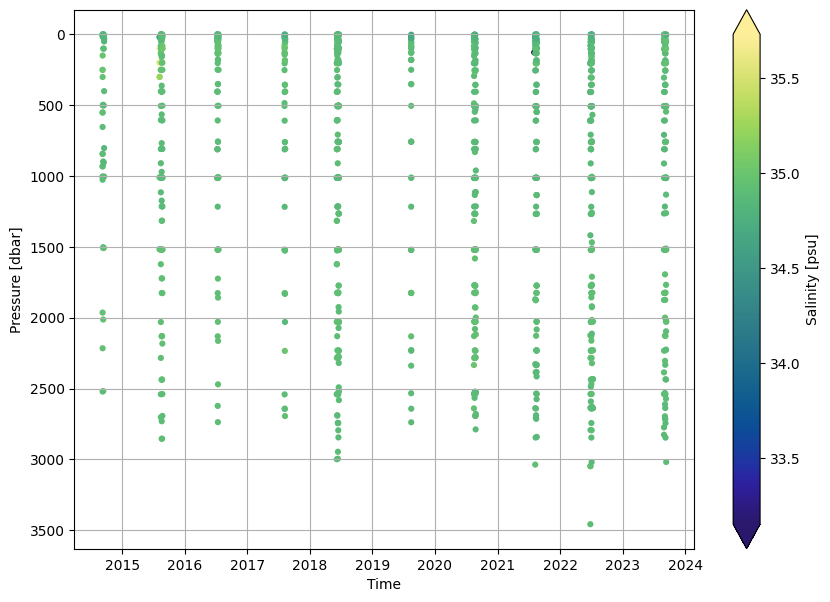

In [18]:
fig, ax = plt.subplots(figsize=(10, 7))
ax.invert_yaxis()
plt.scatter(x=discrete_time, y=df_ctd_discr_all_qc["CTD_Pressure"], s=20,
            c=df_ctd_discr_all_qc["Discrete_Salinity"], cmap=cmap_salt,
            edgecolors="none", vmin=salmin_qc, vmax=salmax_qc)
plt.grid()
plt.colorbar(label="Salinity [psu]", extend='both')
ax.set_ylabel("Pressure [dbar]")
ax.set_xlabel("Time")

Dataset 1: Quick map visualization prior to geographic subsetting

Note: this activity is situated at the end of Session 1: 1st breakout; it would more naturally fit earlier but we want the 1st breakout to achieve the salinity by depth plot.

In [19]:
# Show where all the good data are
# * code in this cell was generated by ChatGPT
import folium
from folium import LatLngPopup

# Remove rows with missing coordinates
df = df_ctd_discr_all_qc.dropna(subset=["Start_Latitude", "Start_Longitude"])

# Center map on the average location
center_lat = df["Start_Latitude"].mean()
center_lon = df["Start_Longitude"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=8
)

# Add points
for _, row in df.iterrows():
    folium.CircleMarker(
        location=[row["Start_Latitude"], row["Start_Longitude"]],
        radius=3,
        color="blue",
        fill=True,
        fill_opacity=0.7
    ).add_to(m)

m.add_child(LatLngPopup())

m

## Access Strategy 2: Loading a subset using a URL pattern (ERDDAP URL)


### Generate a URL using the [ERDDAP Data Access Form](https://erddap.bco-dmo.org/erddap/tabledap/bcodmo_dataset_911407_v1.html)
If using the ERDDAP Data Access Form, file type .csvp provides a single header row.

If using the ERDDAP Data Access Form, one can subset (e.g., select variables of interest, and ranges within) prior to loading the data.

In [20]:
# load ooi_subset from ERDDAP
# then do steps above for disc sal qc to make this new dataframe equivalent to relevant content within ooi_subset from coding within cell above
erddap_url = "https://erddap.bco-dmo.org/erddap/tabledap/bcodmo_dataset_911407_v1.csv?Cruise%2CTarget_Asset%2CStart_Latitude%2CStart_Longitude%2CStart_Time%2CCast%2CNiskin_Bottle_Position%2CCTD_Bottle_Closure_Time%2CCTD_Pressure%2CCTD_Pressure_Flag%2CDiscrete_Salinity%2CDiscrete_Salinity_Flag&Start_Latitude%3E=59.5&Start_Latitude%3C=60.5&Start_Longitude%3E=-40&Start_Longitude%3C=-39"

# Load the data subset into a dataframe
# skiprows is used here because ERDDAP provides the second row with units,
#   we just want column names followed by data rows so we are skipping units row.
#   We can refer to the dataset metadata to find the units.
df_ctd_discr_spatial_erddap_url = pd.read_csv(erddap_url, skiprows=[1])

# Call head() to check that the data was read in correctly
df_ctd_discr_spatial_erddap_url.head()

,Cruise,Target_Asset,Start_Latitude,Start_Longitude,Start_Time,Cast,Niskin_Bottle_Position,CTD_Bottle_Closure_Time,CTD_Pressure,CTD_Pressure_Flag,Discrete_Salinity,Discrete_Salinity_Flag
0,KN221-04,GI01SUMO,59.924168,-39.509335,2014-09-11T22:48:32.000Z,5,2.0,2014-09-11T23:17:06.000Z,1502.957,*0000000000000100,34.9323,*0000000000000100
1,KN221-04,GI01SUMO,59.924168,-39.509335,2014-09-11T22:48:32.000Z,5,4.0,2014-09-11T23:28:19.000Z,899.222,*0000000000000100,34.8664,*0000000000000100
2,KN221-04,GI01SUMO,59.924168,-39.509335,2014-09-11T22:48:32.000Z,5,6.0,2014-09-11T23:36:09.000Z,499.163,*0000000000000100,34.8934,*0000000000000100
3,KN221-04,GI01SUMO,59.924168,-39.509335,2014-09-11T22:48:32.000Z,5,8.0,2014-09-11T23:44:03.000Z,103.084,*0000000000000100,NaN,NaN
4,KN221-04,GI01SUMO,59.924168,-39.509335,2014-09-11T22:48:32.000Z,5,10.0,2014-09-11T23:44:22.000Z,103.228,*0000000000000100,34.9467,*0000000000000100


In [21]:
df_ctd_discr_spatial_erddap_url.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1277 entries, 0 to 1276
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Cruise                   1277 non-null   object 
 1   Target_Asset             1277 non-null   object 
 2   Start_Latitude           1277 non-null   float64
 3   Start_Longitude          1277 non-null   float64
 4   Start_Time               1277 non-null   object 
 5   Cast                     1277 non-null   int64  
 6   Niskin_Bottle_Position   1268 non-null   float64
 7   CTD_Bottle_Closure_Time  1267 non-null   object 
 8   CTD_Pressure             1267 non-null   float64
 9   CTD_Pressure_Flag        1267 non-null   object 
 10  Discrete_Salinity        720 non-null    float64
 11  Discrete_Salinity_Flag   721 non-null    object 
dtypes: float64(5), int64(1), object(6)
memory usage: 119.8+ KB


In [22]:
# account for any NAs in ooi_subset["CTD_Bottle_Closure_Time (unitless)"]
#len(ooi_subset["CTD_Bottle_Closure_Time (unitless)"])
ooi_subset = df_ctd_discr_spatial_erddap_url.dropna(subset=["CTD_Bottle_Closure_Time"])
len(df_ctd_discr_spatial_erddap_url["CTD_Bottle_Closure_Time"])

1277

In [23]:
# Convert the CTD Bottle Closure Time to a datetime data type
df_ctd_discr_spatial_erddap_url["CTD_Bottle_Closure_Time"] = pd.to_datetime(df_ctd_discr_spatial_erddap_url["CTD_Bottle_Closure_Time"], yearfirst=True, utc=True)
df_ctd_discr_spatial_erddap_url.dtypes["CTD_Bottle_Closure_Time"]

datetime64[ns, UTC]

## Repeat transform

## Repeat apply QC flags

In [24]:
# We have to recalculate the flags for the mask to be in the correct positions for the subset

# Assign "Acceptable" flags to QARTOD
flag1 = "*0000000000000100" # Good 1 in Bit Position 2 (i.e., 3rd from right)
flag2 = "*0000000000000101" # this example had 2 unique "Acceptable" flags

df_ctd_discr_spatial_erddap_url.loc[df_ctd_discr_spatial_erddap_url['Discrete_Salinity_Flag'] == flag1, 'Discrete_Salinity_Flag'] = 1   # assign QARTOD Good
df_ctd_discr_spatial_erddap_url.loc[df_ctd_discr_spatial_erddap_url['Discrete_Salinity_Flag'] == flag2, 'Discrete_Salinity_Flag'] = 1   # assign QARTOD Good

# again display unique Discrete Sample flags
df_ctd_discr_spatial_erddap_url['Discrete_Salinity_Flag'].unique() # display unique for parameter of interest
#pd.unique(ooi_irm

array([1, nan, '*0000000000001001'], dtype=object)

In [25]:
#get a mask for where there are good salinities in the ooi subset
# Subset Data Frame to Discrete Samples with Acceptable flags
df_ctd_discr_spatial_erddap_url_qc = df_ctd_discr_spatial_erddap_url.query("Discrete_Salinity_Flag==1")

print(f"This subset of Discrete Samples with Acceptable flags reduced the total data points from {len(df_ctd_discr_spatial_erddap_url)} to {len(df_ctd_discr_spatial_erddap_url_qc)}")


This subset of Discrete Samples with Acceptable flags reduced the total data points from 1277 to 699


## Repeat visualize

In [26]:
# steps as above but for new dataframe
# set up time for matplotlib plots (subset of data)
discrete_time_subset = df_ctd_discr_spatial_erddap_url_qc["CTD_Bottle_Closure_Time"].values

# Create a matplotlib-friendly numeric time array
discrete_mpl_time_subset = mpl.dates.date2num(discrete_time_subset)

# Create normalizer for colorbar representing the full date range
normalizer_subset = Normalize(discrete_mpl_time_subset[0], discrete_mpl_time_subset[-1])

# Create tick locator for using time as the color scale
locator_subset = AutoDateLocator()



In [27]:
# determine max min for parameter of interest
salmax = df_ctd_discr_spatial_erddap_url_qc["Discrete_Salinity"].max()
salmin = df_ctd_discr_spatial_erddap_url_qc["Discrete_Salinity"].min()
print(f"Max: {salmax} | Min: {salmin}")


Max: 35.0303 | Min: 34.5686


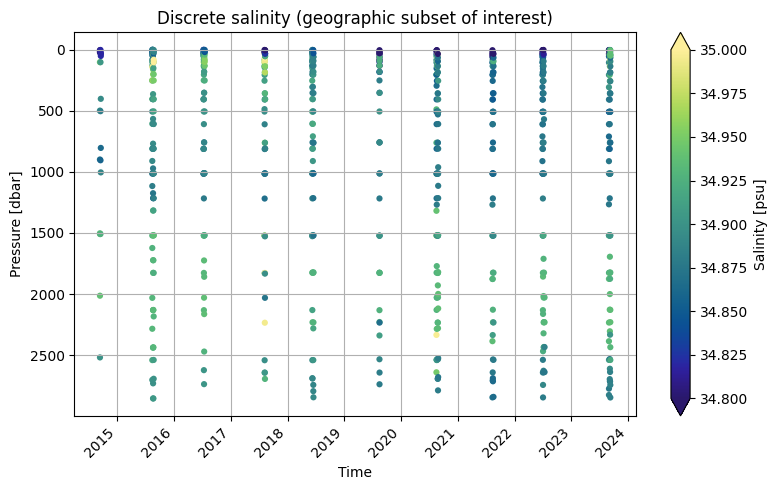

In [28]:
# plot code from JP class differs from initial plot code above
plt.figure(figsize=(8, 5))

plt.scatter(
    x=df_ctd_discr_spatial_erddap_url_qc["CTD_Bottle_Closure_Time"],
    y=df_ctd_discr_spatial_erddap_url_qc["CTD_Pressure"],
    s=20,
    c=df_ctd_discr_spatial_erddap_url_qc["Discrete_Salinity"],
    cmap=cmo.haline,  # colormap from cmocean, designed for salinity (perceptually uniform, accessible colors)
    edgecolors="none",
    vmin=34.8, # use salmin
    vmax=35 # use salmax
)

plt.gca().invert_yaxis()
plt.grid()
plt.colorbar(label="Salinity [psu]", extend="both")
plt.ylabel("Pressure [dbar]")
plt.xlabel("Time")
plt.title("Discrete salinity (geographic subset of interest)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

# Access Strategy 3: Loading the same subset as strategy 2, but this time use the library erdappy

### Extract same subset without having to create a long URL

In [29]:
# use erddapy to extract same subset as URL pattern

## Dataset 1: Record your data citation

Record a data citation for the source data you used. You can get the template for citing the data (or subset) used by clicking the "Cite Dataset" button on the dataset landing page.

# SUPPLEMENTARY DATASET for Session 1
*   Overlay one post-calibrated CTD profile via static NCEI URL
*   Overlay all matching post-calibrated CTD profiles downloaded from NCEI (requires additional notebook)


